In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Reading the dataset
df = pd.read_csv("Car details v3.csv")
df

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8123,Hyundai i20 Magna,2013,320000,110000,Petrol,Individual,Manual,First Owner,18.5 kmpl,1197 CC,82.85 bhp,113.7Nm@ 4000rpm,5.0
8124,Hyundai Verna CRDi SX,2007,135000,119000,Diesel,Individual,Manual,Fourth & Above Owner,16.8 kmpl,1493 CC,110 bhp,"24@ 1,900-2,750(kgm@ rpm)",5.0
8125,Maruti Swift Dzire ZDi,2009,382000,120000,Diesel,Individual,Manual,First Owner,19.3 kmpl,1248 CC,73.9 bhp,190Nm@ 2000rpm,5.0
8126,Tata Indigo CR4,2013,290000,25000,Diesel,Individual,Manual,First Owner,23.57 kmpl,1396 CC,70 bhp,140Nm@ 1800-3000rpm,5.0


In [3]:
# Getting insights about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   object 
 9   engine         7907 non-null   object 
 10  max_power      7913 non-null   object 
 11  torque         7906 non-null   object 
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 825.6+ KB


In [4]:
# Getting the percentange of the missing values
(df.isna().sum()/len(df)) * 100

name             0.000000
year             0.000000
selling_price    0.000000
km_driven        0.000000
fuel             0.000000
seller_type      0.000000
transmission     0.000000
owner            0.000000
mileage          2.718996
engine           2.718996
max_power        2.645177
torque           2.731299
seats            2.718996
dtype: float64

## Findings:
- There are 8128 rows, 13 columns
- Out of the 13 columns 5 have missing values:
* **mileage - 2.7%**
* **engine - 2.7%**
* **max_power - 2.6%**
* **torque - 2.7%**
* **seats - 2.7%**

In [5]:
# Getting statistical summary of the dataset
df.describe()

,year,selling_price,km_driven,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,5.416719
std,4.044249,8.062534e+05,5.655055e+04,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,14.000000


# Feature Selection

In [6]:
make= df["name"].str.split(" ",n= 1, expand= True)[0]
df.insert(loc= 0, column= "make", value= make)

# Deleting the "name" column
df.drop(columns= "name", inplace= True)

In [7]:
# Removing the 'kmpl', 'CC', 'bhp', '@----rpm'
df["mileage"] = df["mileage"].str.split("kmpl").str[0].str.extract('(\d+\.?\d*)')[0].astype(float)
df["engine"] = df["engine"].str.strip("CC").str.extract('(\d+\.?\d*)')[0].astype(float)
df["max_power"] = df["max_power"].str.strip("bhp").str.extract('(\d+\.?\d*)')[0].astype(float)
df["torque"] = df["torque"].str.split("@").str[0].str.extract('(\d+\.?\d*)')[0].astype(float)
# for ('(\d+\.?\d*)') 
# \d+ means one or more digits
# \. means optional decimal poin
#     # \d* means optional digits after decimal point


<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:5: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:5: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Jeremy\AppData\Local\Temp\ipykernel_36088\2601670500.py:2: SyntaxWarning: invalid escape sequence '\d'
  df["mileage"] = df["mileage"].str.split("kmpl").str[0].str.extract('(\d+\.?\d*)')[0].astype(float)
C:\Users\Jeremy\AppData\Local\Temp\ipykernel_36088\2601670500.py:3: SyntaxWarning: invalid escape sequence '\d'
  df["engine"] = df["engine"].str.strip("CC").str.extract('(\d+\.?\d*)')[0].astype(float)
C:\Users\Jeremy\AppData\Local\Temp\ipykernel_36088\2601670500.py:4: SyntaxWarning: invalid escape sequence '\d'
  df["max_power"] = df["max_power"].str.strip("bhp").str.extract('(\d+\.?

In [8]:
# After changes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   make           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   float64
 9   engine         7907 non-null   float64
 10  max_power      7912 non-null   float64
 11  torque         7906 non-null   float64
 12  seats          7907 non-null   float64
dtypes: float64(5), int64(3), object(5)
memory usage: 825.6+ KB


In [9]:
# Changing the data type to categorical to some columns
cat_cols = ["fuel", "seller_type", "transmission", "owner"]
for cat in cat_cols:
    df[cat] = df[cat].astype("category")

## Missing Values

In [10]:
# Getting the sum of missing values in each columns
df.isna().sum()

make               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        216
torque           222
seats            221
dtype: int64

In [11]:
# Getting a dataframe of all the missing values in the engine column
df[df["engine"].isna()]

,make,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
13,Maruti,2007,200000,80000,Petrol,Individual,Manual,Second Owner,NaN,NaN,NaN,NaN,NaN
31,Fiat,2003,70000,50000,Petrol,Individual,Manual,Second Owner,NaN,NaN,NaN,NaN,NaN
78,Tata,2003,50000,70000,Diesel,Individual,Manual,First Owner,NaN,NaN,NaN,NaN,NaN
87,Maruti,2015,475000,78000,Diesel,Dealer,Manual,First Owner,NaN,NaN,NaN,NaN,NaN
119,Maruti,2010,300000,120000,Diesel,Individual,Manual,Second Owner,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7846,Toyota,2000,200000,100000,Diesel,Individual,Manual,First Owner,NaN,NaN,NaN,NaN,NaN
7996,Hyundai,2000,140000,50000,Petrol,Individual,Manual,Second Owner,NaN,NaN,NaN,NaN,NaN
8009,Hyundai,2006,145000,80000,Petrol,Individual,Manual,Second Owner,NaN,NaN,NaN,NaN,NaN
8068,Ford,2017,580000,165000,Diesel,Individual,Manual,First Owner,NaN,NaN,NaN,NaN,NaN


In [12]:
# Since the missing values are 98% on the same row, the rows will be droppped 
# And the missing values only account for 2.7% of the dataset
df = df.drop(index= df[df["torque"].isna()].index)

# Resetting the indexes
df = df.reset_index()

# Droping the original index column
df = df.drop(columns= "index")

In [13]:
# Checking for duplicates
df[df.duplicated()]

,make,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
281,Hyundai,2017,450000,35000,Petrol,Individual,Manual,First Owner,18.90,1197.0,82.00,114.0,5.0
286,Maruti,2012,330000,50000,Petrol,Individual,Manual,Second Owner,18.60,1197.0,85.80,114.0,5.0
357,Jaguar,2017,2625000,9000,Diesel,Dealer,Automatic,First Owner,13.60,1999.0,177.00,430.0,5.0
358,Lexus,2019,5150000,20000,Petrol,Dealer,Automatic,First Owner,22.37,2487.0,214.56,202.0,5.0
359,Jaguar,2017,3200000,45000,Diesel,Dealer,Automatic,First Owner,19.33,1999.0,177.00,430.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7769,Renault,2018,1265000,12000,Diesel,Individual,Manual,First Owner,20.37,1461.0,108.45,240.0,5.0
7770,Maruti,2019,1025000,32000,Diesel,Individual,Manual,First Owner,28.09,1248.0,88.50,200.0,5.0
7895,Maruti,2015,625000,50000,Diesel,Individual,Manual,First Owner,26.59,1248.0,74.00,190.0,5.0
7904,Tata,2013,290000,25000,Diesel,Individual,Manual,First Owner,23.57,1396.0,70.00,140.0,5.0


- There are no duplicates since the rows are different from each other in some features.


# EDA
## ANALYSIS

<Axes: xlabel='fuel', ylabel='selling_price'>

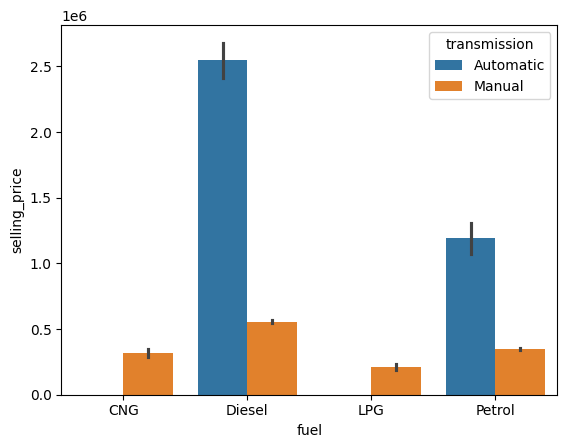

In [14]:
sns.barplot(data= df,
            x= "fuel",
            y= "selling_price",
            hue= "transmission")

- From the graph, The diesel and Petrol tend to perform better sincc they are the commonly used fuel to vehicles.
- The shocking bit is that CNG is out perfoming Petrol on manual car. This would be as a result of the growing use of eco-friendly fuels.
- Another shocking bit is that there are no automatic cng and lpg powered vehicles which is a shock since many users prefer the automatic over the manual.
- The diesel cars are out perfoming any other fuel powered car in terms of prices to due to the wide use of diesel cars in heavy machinery due to high torque.  

<Axes: xlabel='seller_type', ylabel='selling_price'>

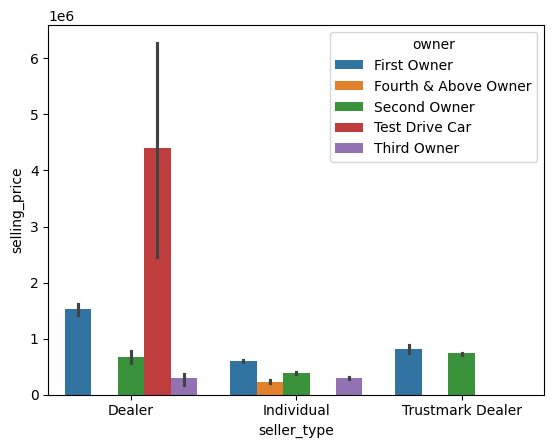

In [15]:
sns.barplot(data= df,
            x= "seller_type",
            y= "selling_price",
            hue= "owner")

- Dealer sell type performs better than any other sell type due to the high trust and consistency over the years to the customers. Customers like trust and a good portfolio of what you offer them.
- The test drive cars performs way better than the used cars do to 
    1. The status the car comes with. Customers prefer a new car due to the status they acquire with the new car.
    2. For a new car, the maintenance is assured.
    3. A new car from the dealearship comes with some perks like warranty, free service for some years.
- The test drive cars only appears to the dealer sell type this is because it has 0 zero mileage. Straight from the factory.

- Cars owned by a previous client tend to do well  in all  the sell type due to some reasons:
    1. Low mileage.
    2. Good maintenance.
    3. Good quality.

- The trustmark dealer perfoms poorly due to:
    1. Unpopular among majority of customers.
    2. Untrusted.

In [16]:
df.head(1)

,make,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4,1248.0,74.0,190.0,5.0


<Axes: xlabel='km_driven', ylabel='selling_price'>

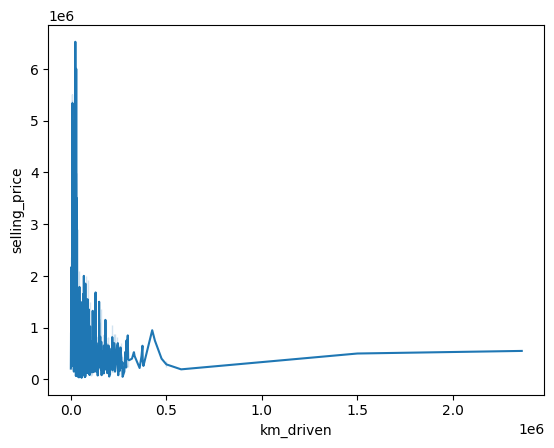

In [17]:
sns.lineplot(data= df,
             x= "km_driven",
             y= "selling_price")

<Axes: xlabel='year', ylabel='selling_price'>

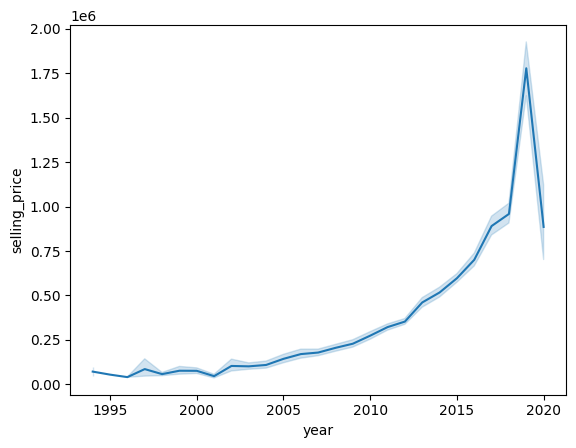

In [18]:
sns.lineplot(data= df,
             x= "year",
             y= "selling_price"
             )

In [19]:
df.head(1)

,make,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4,1248.0,74.0,190.0,5.0


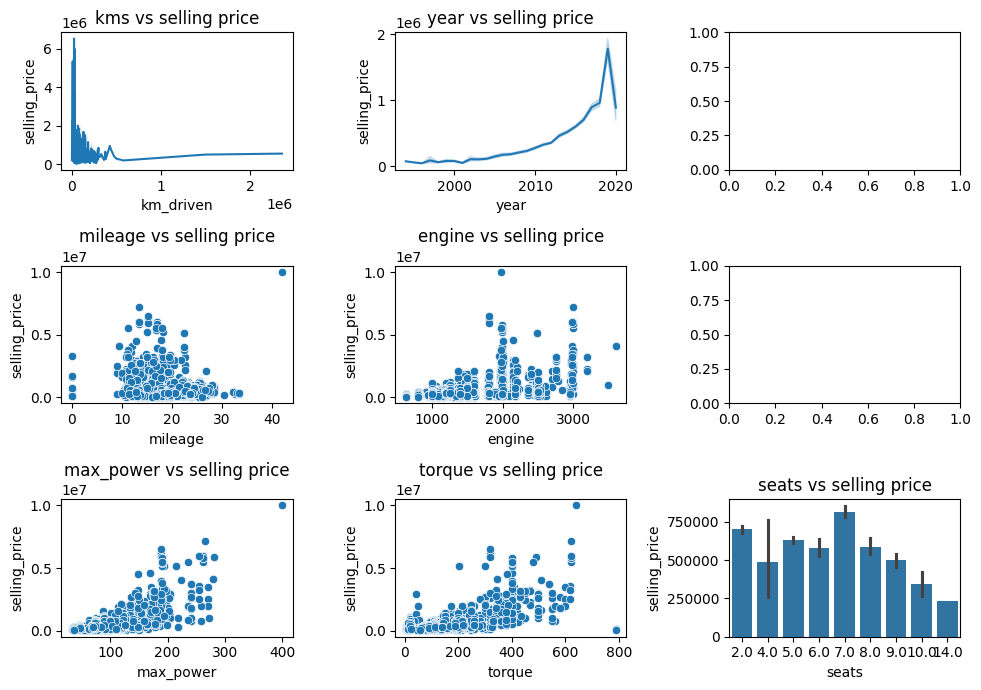

In [20]:
fig, axes = plt.subplots(3, 3, figsize=(10,7))

# kms
sns.lineplot(data= df,
             x= "km_driven",
             y= "selling_price",
             ax= axes[0,0])
axes[0,0].set_title("kms vs selling price")

# year
sns.lineplot(data= df,
             x= "year",
             y= "selling_price",
             ax= axes[0,1])
axes[0,1].set_title("year vs selling price")

# mileage
sns.scatterplot(data= df,
                x= "mileage", 
                y= "selling_price",
                ax= axes[1,0])
axes[1,0].set_title("mileage vs selling price")

# engine
sns.scatterplot(data= df,
                x= "engine", 
                y= "selling_price",
                ax= axes[1,1])
axes[1,1].set_title("engine vs selling price")

# max_power
sns.scatterplot(data= df,
                x= "max_power", 
                y= "selling_price",
                ax= axes[2,0])
axes[2,0].set_title("max_power vs selling price")

# torque
sns.scatterplot(data= df,
                x= "torque", 
                y= "selling_price",
                ax= axes[2,1])
axes[2,1].set_title("torque vs selling price")

# seats
sns.barplot(data= df,
                x= "seats", 
                y= "selling_price",
                ax= axes[2,2])
axes[2,2].set_title("seats vs selling price")

# Better spacing
plt.tight_layout()
plt.show()


#### kms
- Cars with low mileage are especially those belowe 300000kms have a higher selling price due to:
    1. The quality is good. No major expenses on the client after purchase.
    2. With low mileage the maintenance will be good.
    3. The car feels as brand new

#### year
- The latest the car, the higher the price due to more features being added from the previous model.

#### mileage
- The average mileage of cars per km/l is around 19 - 25. For this, the cars with the mileage around this zone has an average selling price of about 50,000
- With one outlier it shows the car with high mileage tends to sell at a higher price.

#### engine
- The average engine is about 1800 to 2100. This gives the car enough power for daily tasks and still maintain a low fuel consumption leading to high selling price.

#### power
- For daily tasks a client requires a car that produces power of 180 - 250hp. This reduces the fuel consumption.
- With high power, the selling price is also high

#### torque
- Same as power, many clients need a car with just enough torque to run the day to day activities, hence the selling price is average.

#### seats
- The higher number of seats leads to higher selling price because the vehicle is for commercial purposes.
- The 2 seater vehicles have a higherselling price because some of the vehicles are considered rare, or sporty.

## Modelling

In [21]:
# Training and teating the data
from sklearn.model_selection import train_test_split

# Getting the independent and dependent features.
# Independent
X = df.drop(columns="selling_price")

# Dependent 
y= df["selling_price"]

# Splitting the dataset to train and test data.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.3, random_state= 42)

# Getting numeric and categorical columns for encoding
cat_cols = ["make", "seller_type", "transmission", "owner"]
num_cols = ["year", "km_driven", "mileage", "engine" ,"max_power", "torque", "seats",]



In [22]:
# OneHot encoding for categorical columns
from sklearn.preprocessing import OneHotEncoder

# Creating an instance.
one_encoder= OneHotEncoder(drop= 'first', sparse_output= False,handle_unknown='ignore') 
                            # drop= 'first' is to avoid dummy trap
                            # sparse_output= False is to get back an array

# Fit_transforming the X_train             
X_train_cat_encoded = one_encoder.fit_transform(X_train[cat_cols])
# Transforming the X_test
X_test_cat_encoded = one_encoder.transform(X_test[cat_cols])
# NOTE: Never **fit** under X_test

# Getting the columns names
cat_feature_names = one_encoder.get_feature_names_out(cat_cols)

# Getting the categorical X_Train dataframe
cat_train_df = pd.DataFrame(
    X_train_cat_encoded,
    columns=cat_feature_names,
    index=X_train.index
)

# Getting the categorical X_Test dataframe
cat_test_df = pd.DataFrame(
    X_test_cat_encoded,
    columns=cat_feature_names,
    index=X_test.index
)



c:\Users\Jeremy\anaconda3\envs\env\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [23]:
# Numeric columns
from sklearn.preprocessing import StandardScaler

# Initializing the StandardScaler
scaler = StandardScaler()

X_train_num_encoded = scaler.fit_transform(X_train[num_cols])
X_test_num_encoded = scaler.transform(X_test[num_cols])

# Getting the numerical X_train dataframe
num_train_df = pd.DataFrame(
    X_train_num_encoded,
    columns=num_cols,
    index=X_train.index
)

# Getting the numerical X_Test dataframe
num_test_df = pd.DataFrame(
    X_test_num_encoded,
    columns=num_cols,
    index=X_test.index
)

In [24]:
# Combining the categorical X_train dataframe with numerical X_train dataframe
X_train = pd.concat([cat_train_df, num_train_df], axis=1)
# Combining the categorical X_train dataframe with numerical X_train dataframe
X_test  = pd.concat([cat_test_df, num_test_df], axis=1)


In [25]:
from sklearn.linear_model import LinearRegression

# Initializing LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

# Getting the predicted value using the X_test dataframe.
y_pred = model.predict(X_test)

In [26]:
# Evaluating the model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f'Mean Absolute Error: {mae}')
print(f'Mean Squared Error: {mse}')
print(f'Root Mean Squared Error: {rmse}')
print(f'R^2 Score: {r2}')

Mean Absolute Error: 157512.50449721332
Mean Squared Error: 88681418191.47684
Root Mean Squared Error: 297794.2547993108
R^2 Score: 0.8678806378684802
